In [1]:
import numpy as np
import bacco
import matplotlib.pyplot as plt
import scipy
import bacco.probabilistic_bias as pb
import h5py

In [2]:
import os
os.chdir('/mnt/home/fmaion/packages/bias_tools/src/')
import merger_tree_tools as mgt
import plotter as plotter
import cutter as cutter
import saver as saver

In [3]:
os.chdir('/mnt/ceph/users/fmaion/projects/bias_priors/src')
import utils

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
basedir = "/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/"

snap = 90

sigma8 = 0.8159
ns     = 0.9667
tau    = 0.0965
sim_format = 'TNG'
cm_50 = bacco.Simulation(verbose=False, basedir=basedir, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(snap,snap),\
           dm_file="snapdir_%03d/snap_%03d"%(snap,snap), tau=tau,ns = ns, sigma8=sigma8,\
           numpart=512**3, sim_format=sim_format, use_orphans=False)

cm_50.header['Seed'] = 18
cm_50.header['InitialPhase'] = 0.0
cm_50.header['FixedInitialAmplitude'] = False    

sel = np.where( (1e10 * cm_50.sub['MassType'][:,4] > 1e8) )

sort = np.argsort(cm_50.dm['ids'])

dm_pos = cm_50.dm['pos'][sort]
dm_vel = cm_50.dm['vel'][sort]
dm_ids = cm_50.dm['ids'][sort]

2026-02-23 10:24:38,029 bacco.sims : Initialising simulation Default
2026-02-23 10:24:38,030 bacco.sims : try /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_090/snap_090
2026-02-23 10:24:38,038 bacco.sims : Loading /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_090/snap_090
2026-02-23 10:24:38,040 bacco.sims : ...done in 0.0118 s
2026-02-23 10:24:38,106 bacco.sims : Reading 138511 items for SubhaloMassType
2026-02-23 10:24:38,189 bacco.sims : Read data for 8549783/134217728 particles...


/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_090/snap_090.0.hdf5


2026-02-23 10:24:39,231 bacco.sims : Read data for 8549783/134217728 particles...
2026-02-23 10:24:39,240 bacco.sims : Read data for 8499357/134217728 particles...
2026-02-23 10:24:40,325 bacco.sims : Read data for 8499357/134217728 particles...
2026-02-23 10:24:40,335 bacco.sims : Read data for 8455408/134217728 particles...
2026-02-23 10:24:41,438 bacco.sims : Read data for 8455408/134217728 particles...
2026-02-23 10:24:41,447 bacco.sims : Read data for 8483362/134217728 particles...
2026-02-23 10:24:42,585 bacco.sims : Read data for 8483362/134217728 particles...
2026-02-23 10:24:42,593 bacco.sims : Read data for 8409350/134217728 particles...
2026-02-23 10:24:43,724 bacco.sims : Read data for 8409350/134217728 particles...
2026-02-23 10:24:43,734 bacco.sims : Read data for 8333140/134217728 particles...
2026-02-23 10:24:44,864 bacco.sims : Read data for 8333140/134217728 particles...
2026-02-23 10:24:44,873 bacco.sims : Read data for 8292191/134217728 particles...
2026-02-23 10:24

In [6]:
pos_tree = scipy.spatial.KDTree(dm_pos)
d_dm, id_dm = pos_tree.query(cm_50.sub['pos'][sel,:]) # This has to be improved, let's explicitly get the mostbound ID and then match it.


2026-02-23 10:26:15,653 bacco.sims : Reading 138511 items for SubhaloPos


In [7]:
def get_biases(basedir, kd):
    snap = 90
    
    sigma8 = 0.8159
    ns     = 0.9667
    tau    = 0.0965
    sim_format = 'TNG'
    cm_50 = bacco.Simulation(verbose=False, basedir=basedir, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(snap,snap),\
               dm_file="snapdir_%03d/snap_%03d"%(snap,snap), tau=tau,ns = ns, sigma8=sigma8,\
               numpart=512**3, sim_format=sim_format, use_orphans=False)
    
    cm_50.header['Seed'] = 18
    cm_50.header['InitialPhase'] = 0.0
    cm_50.header['FixedInitialAmplitude'] = False    

    sel = np.where( (1e10 * cm_50.sub['MassType'][:,4] > 1e8) )
    
    sort = np.argsort(cm_50.dm['ids'])
    
    dm_pos = cm_50.dm['pos'][sort]
    dm_vel = cm_50.dm['vel'][sort]
    dm_ids = cm_50.dm['ids'][sort]
    
    pos_tree = scipy.spatial.KDTree(dm_pos)

    # These are the variables that need to be measured on a Lagrangian grid
    D_variables = ("J2", "J2=2")
    D_pbm = pb.ProbabilisticBiasManager(cm_50, variables=D_variables, damping_scale=kd, ngrid=192, filt='sharpk')
    
    D_terms = ("J2", "J22", "J2=2")
    D_model = D_pbm.setup_bias_model(pb.TensorBiasND, terms=D_terms, spatial_order=2)
    
    d_dm, id_dm = pos_tree.query(cm_50.sub['pos'][sel,:]) # This has to be improved, let's explicitly get the mostbound ID and then match it.
    q = utils.dmpos_from_ids(dm_ids[id_dm[0,:]], 50000/512)
    print("Done! Lagrangian positions have been obtained")
    
    tr_q, tr_value, tr_mask = D_pbm._define_tracers(tracer_q=q/1e3)
    
    b_gal = D_model.bias_per_object(tr_value)
    
    mstar = np.log10(1e10*cm_50.sub['MassType'][sel,4])[0,:]
    # mass bins
    
    m_edges = np.array([[8.5,9],[9,9.5],[9.5,10],[10,10.5],[10.5,11],[11,11.5],[11.5,12],[12,12.5]])
    m_centers = 0.5 * ( m_edges[:,0] + m_edges[:,1] )
    
    b_gal_mstar = np.zeros((m_edges.shape[0], 3))
    bcov_gal_mstar = np.zeros((m_edges.shape[0],3,3))
    
    mstar_weight = np.zeros(m_edges.shape[0])
    mstar_sel = {}
    
    for i in range(m_edges.shape[0]):
        mstar_sel[i] = np.where( ( mstar > m_edges[i][0] ) & ( mstar < m_edges[i][1] ) )[0]
        mstar_weight[i] = np.mean(mstar[mstar_sel[i]])
    
        b_gal_mstar[i], bcov_gal_mstar[i] = cutter.fit_from_bpo(bpo=b_gal, box=50, IA=False, tr_q=q/1e3, mask=mstar_sel[i])

    return b_gal, mstar, mstar_weight, b_gal_mstar, bcov_gal_mstar

In [8]:
def get_biases_kd(kd):
    # These are the variables that need to be measured on a Lagrangian grid
    D_variables = ("J2", "J2=2")
    D_pbm = pb.ProbabilisticBiasManager(cm_50, variables=D_variables, damping_scale=kd, ngrid=192, filt='sharpk')
    
    D_terms = ("J2", "J22", "J2=2")
    D_model = D_pbm.setup_bias_model(pb.TensorBiasND, terms=D_terms, spatial_order=2)
    
    d_dm, id_dm = pos_tree.query(cm_50.sub['pos'][sel,:])
    q = dmpos_from_ids(id_dm[0,:]+1, 50000/512)
    print("Done! Lagrangian positions have been obtained")
    
    tr_q, tr_value, tr_mask = D_pbm._define_tracers(tracer_q=q/1e3)
    return D_model.bias_per_object(tr_value)

In [9]:
data = np.loadtxt("/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt", skiprows=1,\
                 dtype={'names': ('Name', 'Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor',\
                                  'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s',\
                                  'MaxSfrTimescale', 'FactorForSofterEQS', 'IMFslope', 'SNII_MinMass_Msun',\
                                  'ThermalWindFraction', 'VariableWindSpecMomentum', 'WindFreeTravelDensFac',\
                                  'MinWindVel', 'WindEnergyReductionFactor', 'WindEnergyReductionMetallicity',\
                                  'WindEnergyReductionExponent', 'WindDumpFactor', 'SeedBlackHoleMass',\
                                  'BlackHoleAccretionFactor', 'BlackHoleEddingtonFactor', 'BlackHoleFeedbackFactor',\
                                  'BlackHoleRadiativeEfficiency', 'QuasarThreshold', 'QuasarThresholdPower', 'UVBH0beta',\
                                  'UVBH0Deltaz', 'UVBHepbeta', 'UVBHepDeltaz', 'SNIa_Rate_Norm', 'SNIa_Rate_DTD_power',\
                                  'SofteningComovingType01', 'seed'),
                        'formats': ('U100', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4',\
                                   'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4',\
                                   'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4')} )

In [18]:
basedir = "/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/"
names = ["1P_p1_n2",
        "1P_p1_n1",
        "1P_p1_0", 
        "1P_p1_1",
        "1P_p1_2"]

kd = 0.3

b_gal = {}
mstar = {}
mstar_weight = {}
bgal_mstar = {}
bcov_mstar = {}
pars = np.zeros(len(names))

for i in range(5):
    b_gal[i], mstar[i], mstar_weight[i], bgal_mstar[i], bcov_mstar[i] = get_biases(basedir+names[i], kd)
    for j in range(len(data)):
        if names[i] == data[j][0]:
            pars[i] = data[j][2]

2026-02-23 10:37:37,287 bacco.sims : Initialising simulation Default
2026-02-23 10:37:37,288 bacco.sims : try /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_n2/snapdir_090/snap_090
2026-02-23 10:37:37,297 bacco.sims : Loading /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_n2/snapdir_090/snap_090
2026-02-23 10:37:37,300 bacco.sims : ...done in 0.0127 s
2026-02-23 10:37:37,383 bacco.sims : Reading 82871 items for SubhaloMassType
2026-02-23 10:37:37,470 bacco.sims : Read data for 8600228/134217728 particles...


/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_n2/snapdir_090/snap_090.0.hdf5


2026-02-23 10:37:38,580 bacco.sims : Read data for 8600228/134217728 particles...
2026-02-23 10:37:38,588 bacco.sims : Read data for 8503157/134217728 particles...
2026-02-23 10:37:39,707 bacco.sims : Read data for 8503157/134217728 particles...
2026-02-23 10:37:39,716 bacco.sims : Read data for 8319409/134217728 particles...
2026-02-23 10:37:40,836 bacco.sims : Read data for 8319409/134217728 particles...
2026-02-23 10:37:40,844 bacco.sims : Read data for 8402781/134217728 particles...
2026-02-23 10:37:41,987 bacco.sims : Read data for 8402781/134217728 particles...
2026-02-23 10:37:41,995 bacco.sims : Read data for 8328713/134217728 particles...
2026-02-23 10:37:43,103 bacco.sims : Read data for 8328713/134217728 particles...
2026-02-23 10:37:43,111 bacco.sims : Read data for 8369451/134217728 particles...
2026-02-23 10:37:44,158 bacco.sims : Read data for 8369451/134217728 particles...
2026-02-23 10:37:44,166 bacco.sims : Read data for 8244115/134217728 particles...
2026-02-23 10:37

Done! Lagrangian positions have been obtained


2026-02-23 10:39:14,140 bacco.sims : Reading 122902 items for SubhaloMassType
2026-02-23 10:39:14,542 bacco.sims : Read data for 8404120/134217728 particles...


...

Done! Lagrangian positions have been obtained


2026-02-23 10:45:30,117 bacco.sims : Reading 147509 items for SubhaloMassType
2026-02-23 10:45:30,731 bacco.sims : Read data for 8492685/134217728 particles...


/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_2/snapdir_090/snap_090.0.hdf5


2026-02-23 10:45:33,976 bacco.sims : Read data for 8492685/134217728 particles...
2026-02-23 10:45:34,003 bacco.sims : Read data for 8270209/134217728 particles...
2026-02-23 10:45:37,497 bacco.sims : Read data for 8270209/134217728 particles...
2026-02-23 10:45:37,528 bacco.sims : Read data for 8373814/134217728 particles...
2026-02-23 10:45:41,515 bacco.sims : Read data for 8373814/134217728 particles...
2026-02-23 10:45:41,567 bacco.sims : Read data for 8224721/134217728 particles...
2026-02-23 10:45:44,675 bacco.sims : Read data for 8224721/134217728 particles...
2026-02-23 10:45:44,742 bacco.sims : Read data for 8474118/134217728 particles...
2026-02-23 10:45:48,293 bacco.sims : Read data for 8474118/134217728 particles...
2026-02-23 10:45:48,328 bacco.sims : Read data for 8325752/134217728 particles...
2026-02-23 10:45:51,645 bacco.sims : Read data for 8325752/134217728 particles...
2026-02-23 10:45:51,680 bacco.sims : Read data for 8404695/134217728 particles...
2026-02-23 10:45

Done! Lagrangian positions have been obtained


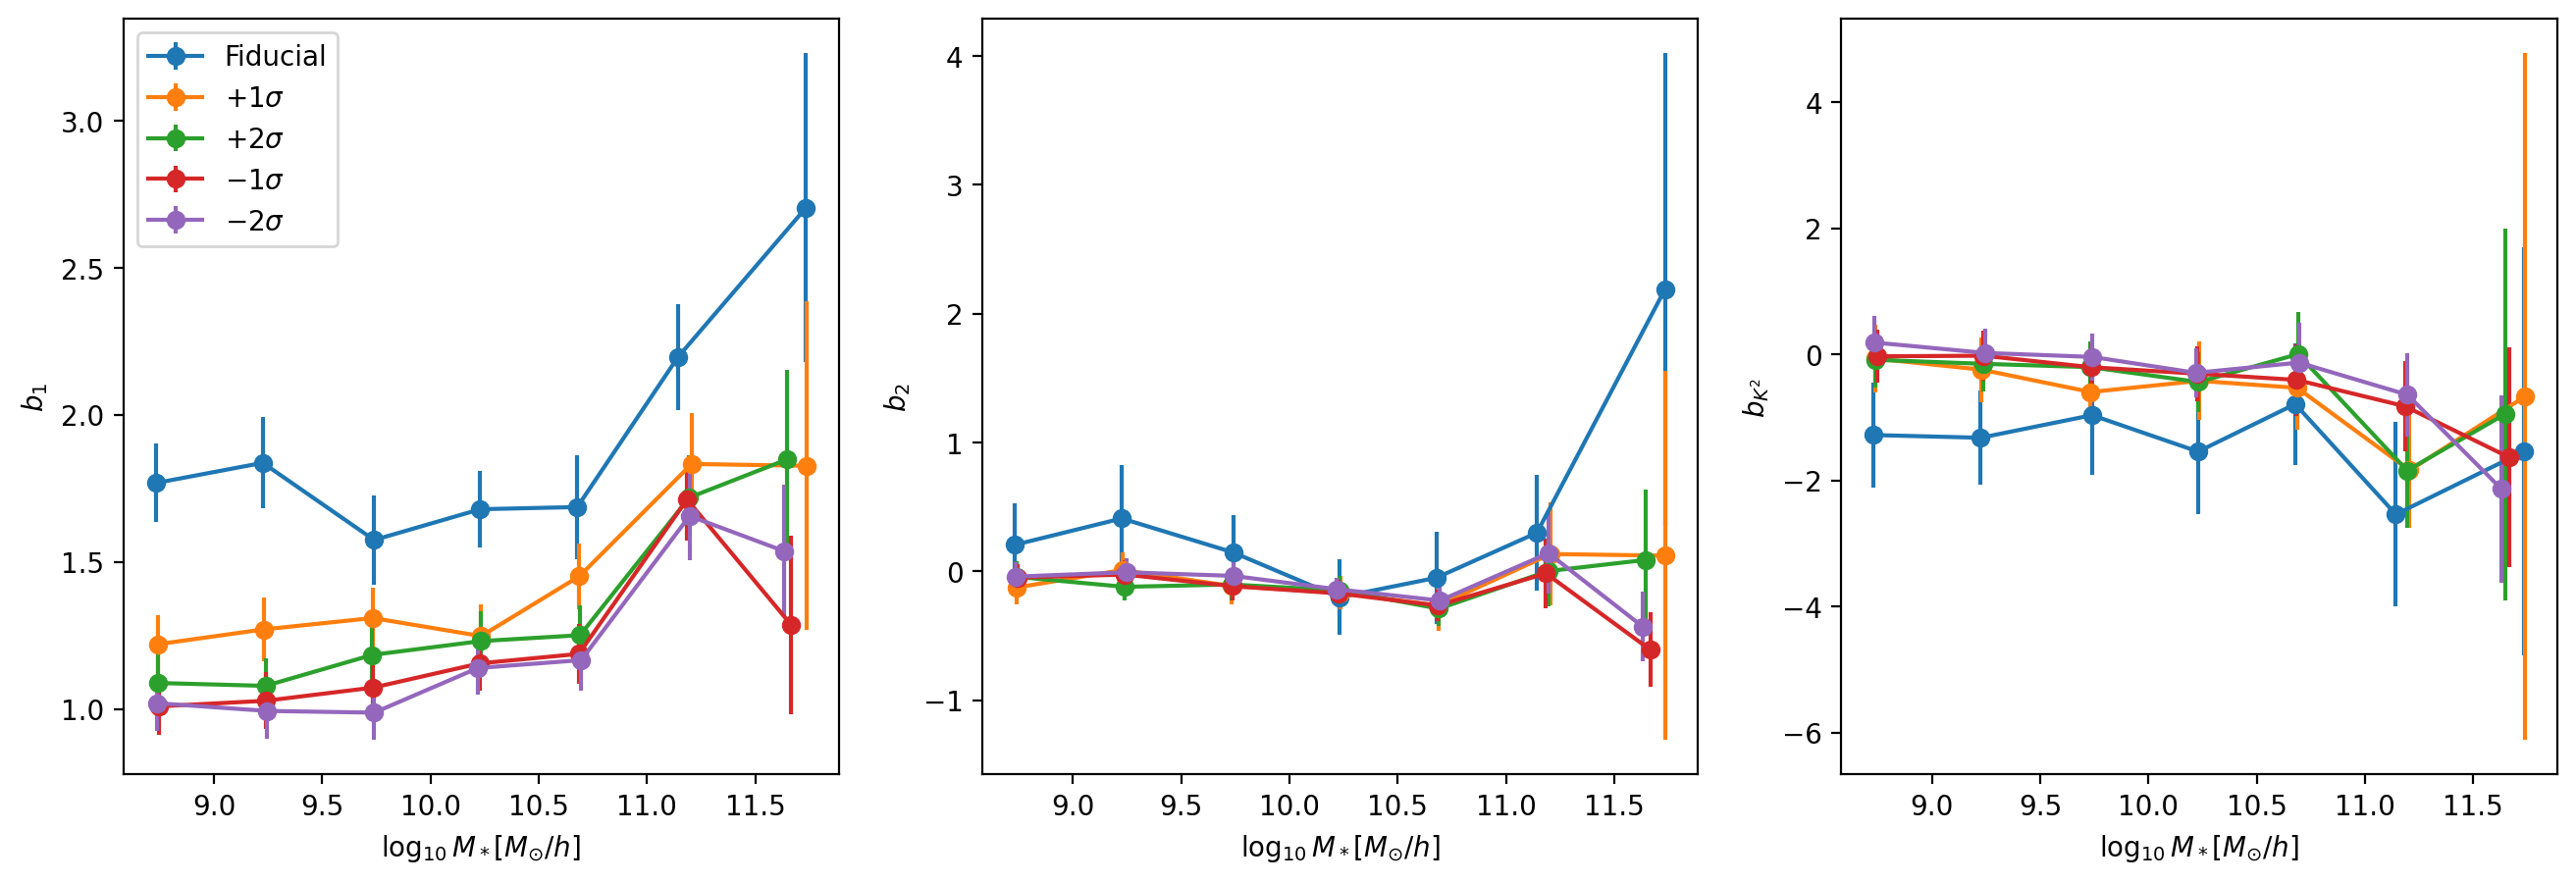

In [20]:
fig, ax = plt.subplots(1, 3, dpi=200, figsize=(16, 5))

labels=['Fiducial', "$+1\\sigma$", "$+2\\sigma$", "$-1\\sigma$", "$-2\\sigma$"]

# ax.scatter(mstar, 1+b_gal[:,0], s=0.1)
ax[0].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[0].set_ylabel("$b_1$")

ax[1].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[1].set_ylabel("$b_2$")

ax[2].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[2].set_ylabel("$b_{K^2}$")

for j in range(5):
    for i in range(3):
        if i==0:
            ax[i].errorbar(mstar_weight[j], 1+bgal_mstar[j][:,i], np.sqrt(bcov_mstar[j][:,i,i]), color='C{:d}'.format(j), marker='o', label=labels[j])
        else:
            ax[i].errorbar(mstar_weight[j], bgal_mstar[j][:,i], np.sqrt(bcov_mstar[j][:,i,i]), color='C{:d}'.format(j), marker='o', label=labels[j])
    
ax[0].legend(loc='upper left')

In [13]:
bgal_mean = {}
bcov_mean = {}

for i in range(5):
    bgal_mean[i], bcov_mean[i] = cutter.fit_from_bpo(bpo=b_gal[i], box=50, IA=False, tr_q=q/1e3, mask=np.where(mstar[i]>)

SyntaxError: invalid syntax (2768663248.py, line 5)

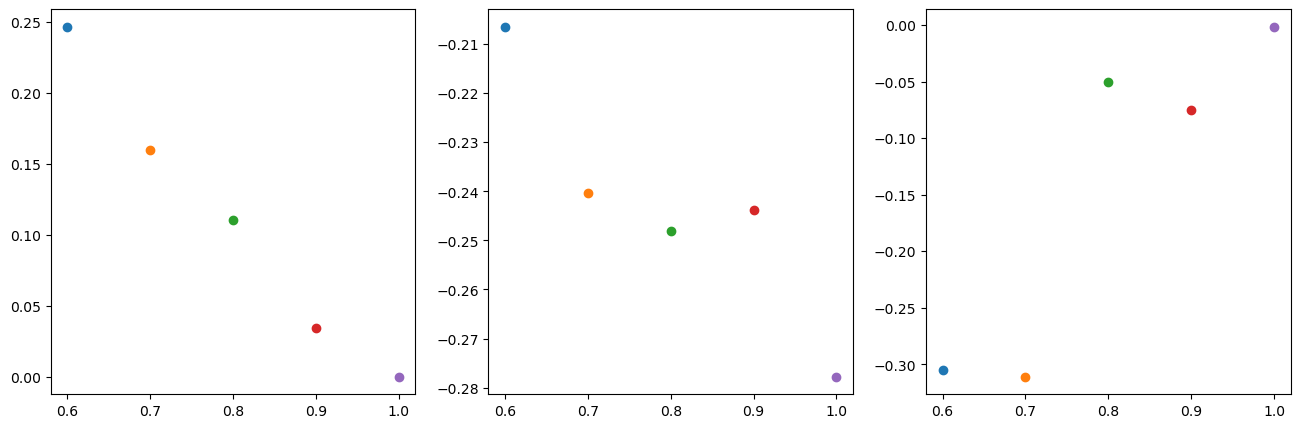

In [122]:
fig, ax = plt.subplots(1, 3, dpi=100, figsize=(16,5))

for i in range(5):
    sel = np.where(mstar[i]>10)
    ax[0].plot(pars[i], np.mean(b_gal[i][sel,0]), marker='o')
    ax[1].plot(pars[i], np.mean(b_gal[i][sel,1]), marker='o')
    ax[2].plot(pars[i], np.mean(b_gal[i][sel,2]), marker='o')

In [11]:
sort = np.argsort(cm_50.dm['ids'])

In [12]:
dm_pos = cm_50.dm['pos'][sort]
dm_vel = cm_50.dm['vel'][sort]
dm_ids = cm_50.dm['ids'][sort]

pos_tree = scipy.spatial.KDTree(dm_pos)

In [15]:
sel = np.where( (1e10 * cm_50.sub['MassType'][:,4] > 1e8) & (cm_50.sub['centrAl']) )

2025-12-08 10:46:50,939 bacco.sims : Reading 160150 items for halo_firstsub
2025-12-08 10:46:51,090 bacco.sims : Reading 160150 items for GroupNsubs


In [117]:
kds = np.asarray([0.1,0.15,0.2,0.3])

b_gal = {}
for i in range(len(kds)):
    b_gal[i] = get_biases_kd(kds[i])

Done! Lagrangian positions have been obtained
Done! Lagrangian positions have been obtained
Done! Lagrangian positions have been obtained
Done! Lagrangian positions have been obtained


In [118]:
mstar = np.log10(1e10*cm_50.sub['MassType'][sel,4])[0,:]

In [119]:
# mass bins
m_edges = np.array([[8.5,9],[9,9.5],[9.5,10],[10,10.5],[10.5,11],[11,11.5],[11.5,12],[12,12.5]])
m_centers = 0.5 * ( m_edges[:,0] + m_edges[:,1] )

b_gal_mstar = {i: np.zeros((m_edges.shape[0], 3)) for i in range(len(kds))}
bcov_gal_mstar = {i: np.zeros((m_edges.shape[0],3,3)) for i in range(len(kds))}

mstar_weight = np.zeros(m_edges.shape[0])
mstar_sel = {}

for j in range(len(kds)):
    for i in range(m_edges.shape[0]):
        mstar_sel[i] = np.where( ( mstar > m_edges[i][0] ) & ( mstar < m_edges[i][1] ) )[0]
        mstar_weight[i] = np.mean(mstar[mstar_sel[i]])
    
        b_gal_mstar[j][i], bcov_gal_mstar[j][i] = cutter.fit_from_bpo(bpo=b_gal[j], box=50, IA=False, tr_q=q/1e3, mask=mstar_sel[i])

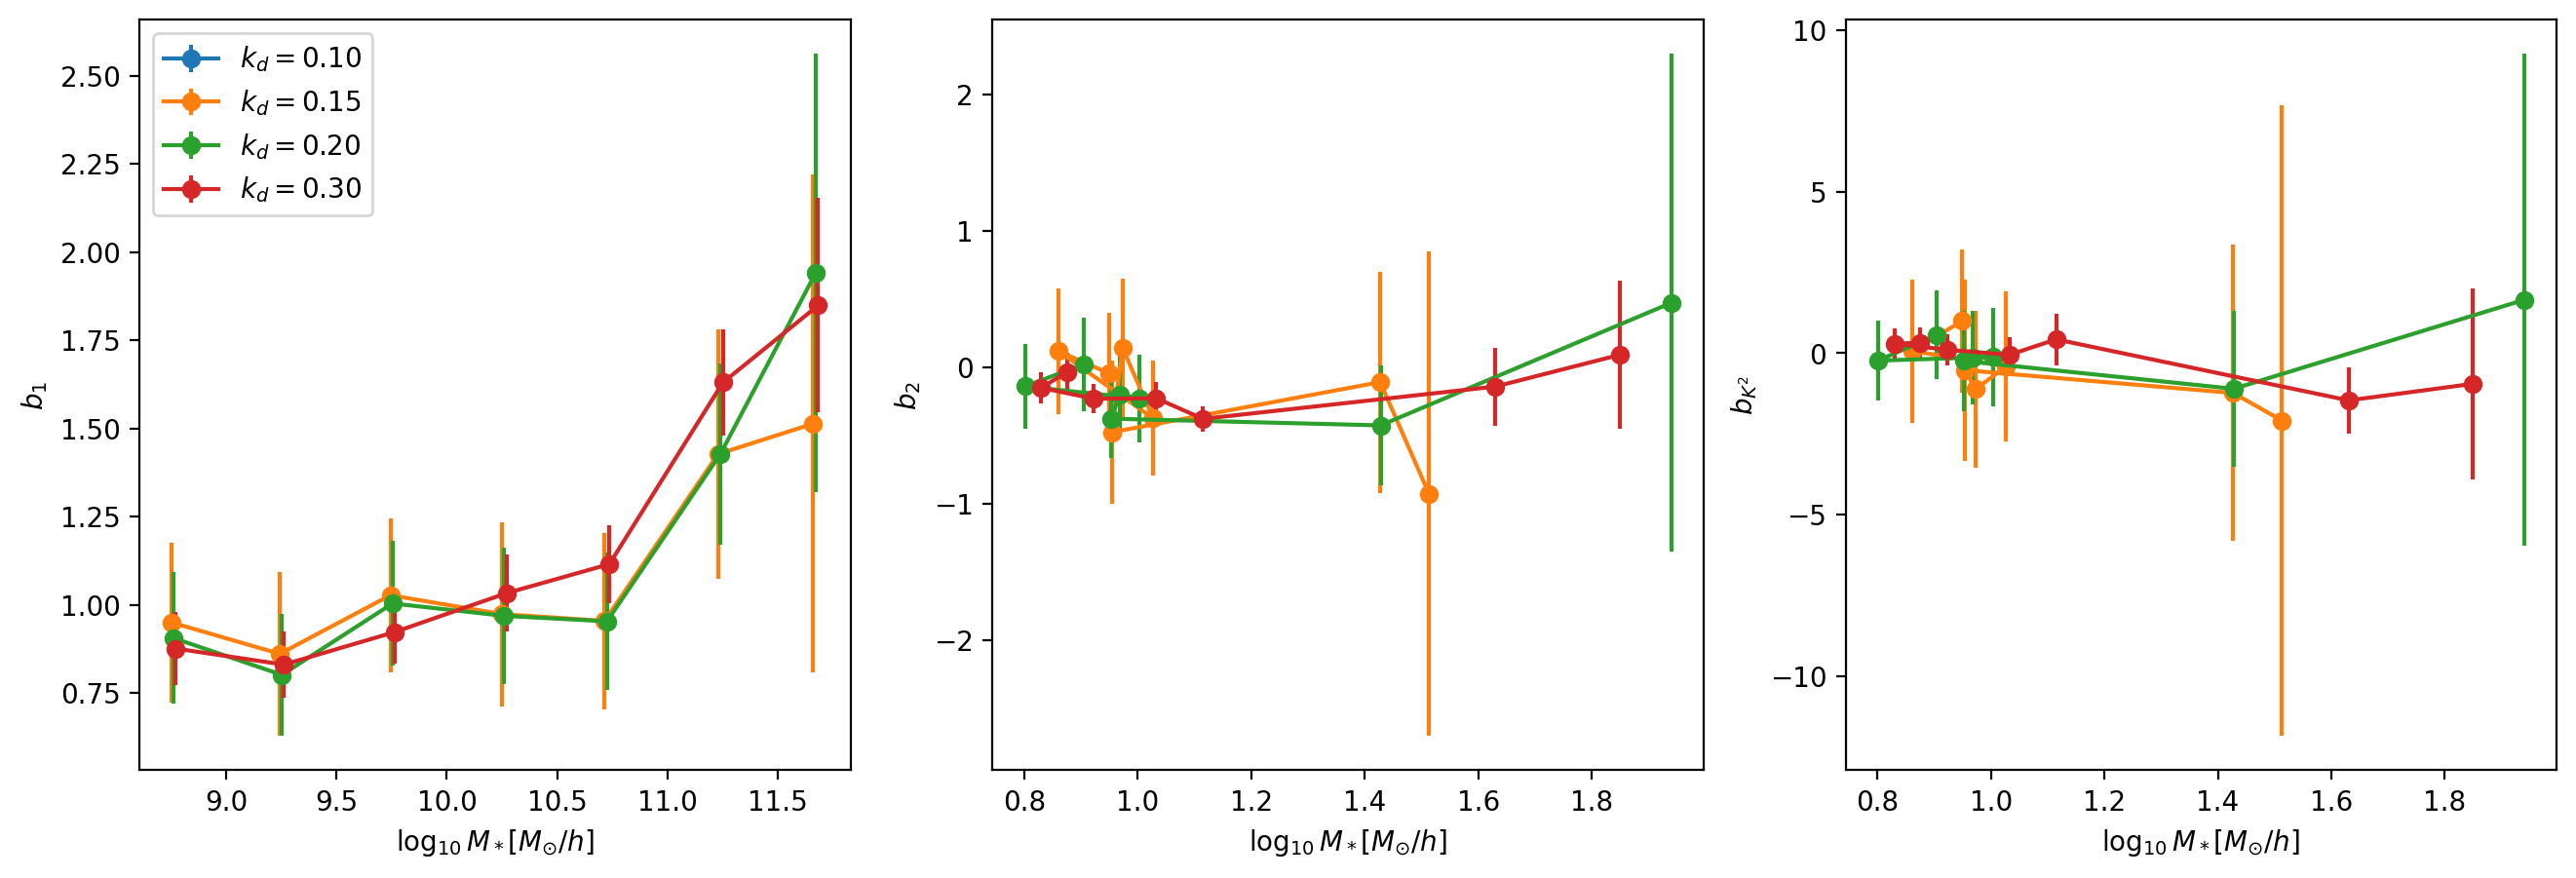

In [120]:
fig, ax = plt.subplots(1, 3, dpi=200, figsize=(16, 5))

# ax.scatter(mstar, 1+b_gal[:,0], s=0.1)
ax[0].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[0].set_ylabel("$b_1$")

ax[1].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[1].set_ylabel("$b_2$")

ax[2].set_xlabel("$\\log_{10} M_*[M_{\\odot}/h]$")
ax[2].set_ylabel("$b_{K^2}$")

for i in range(len(kds)):
    ax[0].errorbar(mstar_weight*(1+0.001*i), 1+b_gal_mstar[i][:,0], np.sqrt(bcov_gal_mstar[i][:,0,0]), color='C{:d}'.format(i), marker='o', label="$k_d={:.2f}$".format(kds[i]) )
    ax[1].errorbar( 1+b_gal_mstar[i][:,0], b_gal_mstar[i][:,1], np.sqrt(bcov_gal_mstar[i][:,1,1]), color='C{:d}'.format(i), marker='o')
    ax[2].errorbar( 1+b_gal_mstar[i][:,0], b_gal_mstar[i][:,2], np.sqrt(bcov_gal_mstar[i][:,2,2]), color='C{:d}'.format(i), marker='o')
    
ax[0].legend(loc='upper left')

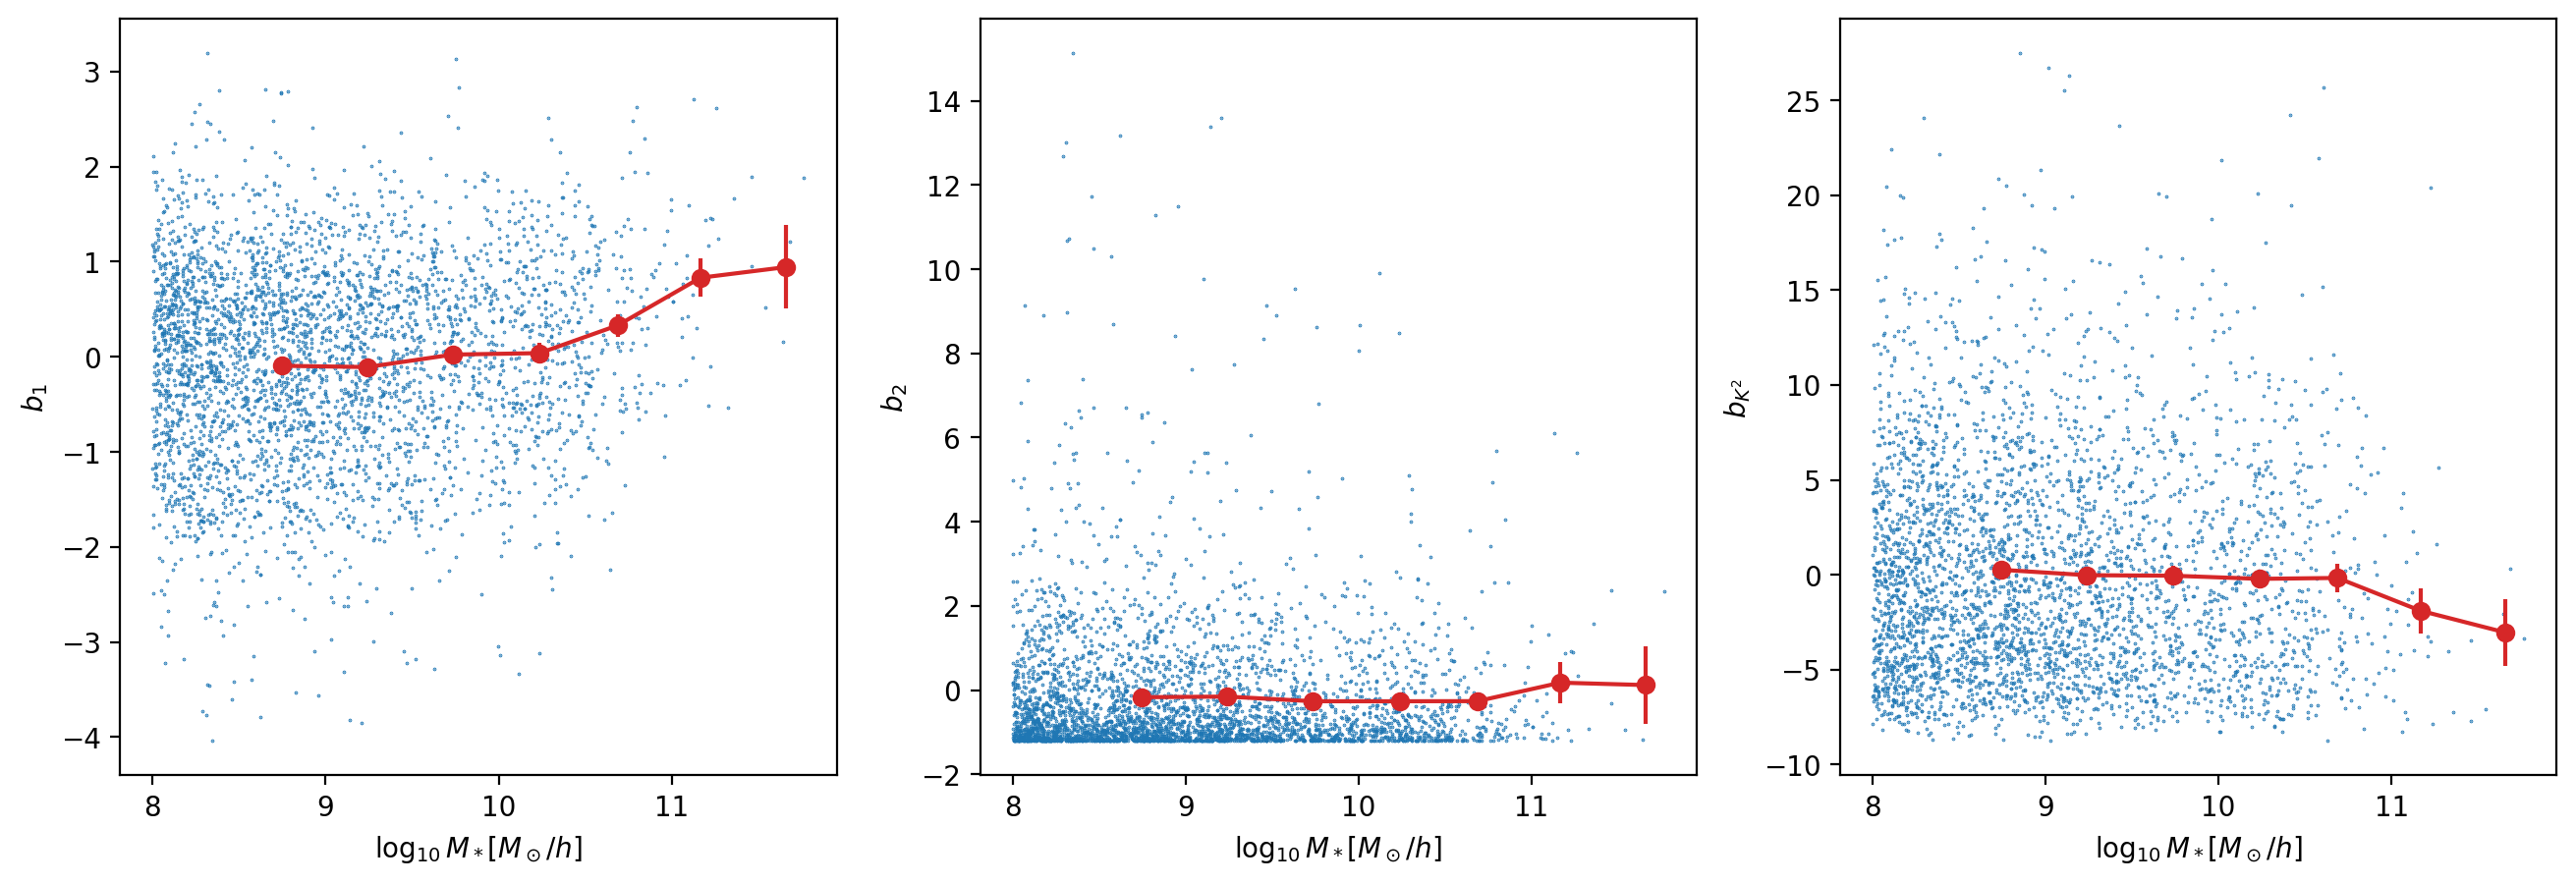

In [27]:
fig, ax = plt.subplots(1, 3, dpi=200, figsize=(16, 5))

ax[0].set_ylabel("$b_1$")
ax[1].set_ylabel("$b_2$")
ax[2].set_ylabel("$b_{K^2}$")

for i in range(3):
    ax[i].set_xlabel("$\\log_{10} M_*[M_\\odot/h]$")
    ax[i].scatter(mstar[3], b_gal[3][:,i], s=0.1, color='C0')
    ax[i].errorbar(mstar_weight[3], bgal_mstar[3][:,i], np.sqrt(bcov_mstar[3][:,i,i]), color='C3', marker='o')

<ErrorbarContainer object of 3 artists>

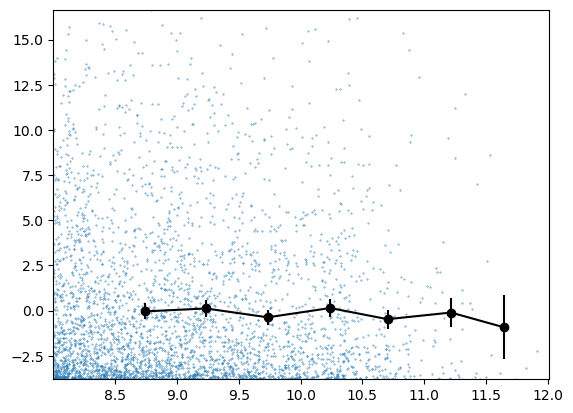

In [72]:
fig, ax = plt.subplots(dpi=100)

ax.set_xscale("linear")


ax.contour(mstar, b_gal[0][:,1], np.ones((len(mstar), len(mstar))), levels=np.linspace(0,1e3,100))
ax.scatter(mstar, b_gal[0][:,1], s=0.1)
ax.errorbar(mstar_weight, b_gal_mstar[0][:,1], np.sqrt(bcov_gal_mstar[0][:,1,1]), color='k', marker='o')

<ErrorbarContainer object of 3 artists>

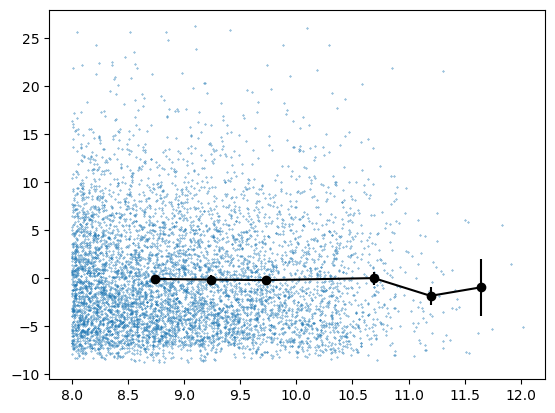

In [37]:
fig, ax = plt.subplots(dpi=100)

ax.set_xscale("linear")

ax.scatter(mstar, b_gal[:,2], s=0.1)
ax.errorbar(mstar_weight, b_gal_mstar[:,2], np.sqrt(bcov_gal_mstar[:,2,2]), color='k', marker='o')

In [12]:
snap_0 = bacco.Simulation(verbose=False, basedir=basedir, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(14,14),
           dm_file='snapdir_%03d/snap_%03d'%(14,14),tau=tau,ns = ns, sigma8=sigma8, numpart=512**3,\
           sim_format=sim_format, use_orphans=False)


2025-12-04 12:07:56,560 bacco.sims : Initialising simulation Default
2025-12-04 12:07:56,561 bacco.sims : try /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_014/snap_014
2025-12-04 12:07:56,611 bacco.sims : Loading /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_014/snap_014
2025-12-04 12:08:00,762 bacco.sims : ...done in 0.0816 s


In [73]:
with h5py.File("/mnt/ceph/users/camels/Sims/IllustrisTNG_DM/L50n512/1P/1P_p1_0/snap_000.hdf5") as f:
    _ID = f['PartType1']['ParticleIDs'][...]
    _pos = f['PartType1']['Coordinates'][...]

sort = np.argsort(_ID)
ID = _ID[sort]
pos = _pos[sort]

In [92]:
dm_d3d = np.empty((10*64**3, 3))
for i in range(10*64**3):
    dm_d3d[i,:] = pos[i,:] - dmpos_from_id(ID[i], 50000/512)[1]
    for j in range(3):
        if dm_d3d[i,j]>25000:
            dm_d3d[i,j] = dm_d3d[i,j] - 50000
        if dm_d3d[i,j]<-25000:
            dm_d3d[i,j] = dm_d3d[i,j] + 50000

In [93]:
np.mean(dm_d3d, axis=0)

array([-127.87231949, -102.19738895,   11.14628556])

In [75]:
for i in range(65):
    print( pos[i] )
    print( dmpo_from_id(ID[i], 50000/512) )
    print("\n")

[49403.105 49805.594 49672.367]
(0, (0.0, 0.0, 0.0))


[49402.656 49790.91  49743.977]
(1, (0.0, 0.0, 97.65625))


[49412.9  49768.71 49831.12]
(2, (0.0, 0.0, 195.3125))


[49410.145 49754.086 49921.6  ]
(3, (0.0, 0.0, 292.96875))


[4.9410805e+04 4.9739488e+04 3.2552120e+01]
(4, (0.0, 0.0, 390.625))


[49411.69    49743.        129.08926]
(5, (0.0, 0.0, 488.28125))


[49408.188   49750.816     227.17264]
(6, (0.0, 0.0, 585.9375))


[49415.055   49748.223     316.46664]
(7, (0.0, 0.0, 683.59375))


[49431.645  49741.2      441.0514]
(8, (0.0, 0.0, 781.25))


[49441.297   49733.74      578.16187]
(9, (0.0, 0.0, 878.90625))


[49437.773  49724.27     674.8489]
(10, (0.0, 0.0, 976.5625))


[49434.453  49720.28     790.3904]
(11, (0.0, 0.0, 1074.21875))


[49443.6    49722.93     918.9787]
(12, (0.0, 0.0, 1171.875))


[49454.59   49732.06    1045.9713]
(13, (0.0, 0.0, 1269.53125))


[49455.656  49738.715   1142.1637]
(14, (0.0, 0.0, 1367.1875))


[49457.57   49748.363   1250.7378]
(15, (0.

In [7]:
print("Dark Matter")
i_dm_min = np.argmin(snap_0.dm['ids'])
print("Minimum DM ID is {:d}".format(snap_0.dm['ids'][i_dm_min]))
print("Position at DM min ID is")
print(snap_0.dm['pos'][i_dm_min+3])

i_dm_max = np.argmax(snap_0.dm['ids'])
print("Maximum DM ID is {:d}".format(snap_0.dm['ids'][i_dm_max]))
print("Position at DM max ID is")
print(snap_0.dm['pos'][i_dm_max])

i_gas_min = np.argmin(snap_0.gas['ids'])
print("Minimum gas ID is {:d}".format(snap_0.gas['ids'][i_gas_min]))
print("Position at gas min ID is")
print(snap_0.gas['pos'][i_gas_min+3])

i_gas_max = np.argmax(snap_0.gas['ids'])
print("Maximum gas ID is {:d}".format(snap_0.gas['ids'][i_gas_max]))
print("Position at gas max ID is")
print(snap_0.gas['pos'][i_gas_max])


2025-11-25 11:18:59,708 bacco.sims : Read data for 8297282/134217728 particles...


Dark Matter
/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_014/snap_014.0.hdf5


2025-11-25 11:19:02,206 bacco.sims : Read data for 8297282/134217728 particles...
2025-11-25 11:19:02,329 bacco.sims : Read data for 8367468/134217728 particles...
2025-11-25 11:19:04,606 bacco.sims : Read data for 8367468/134217728 particles...
2025-11-25 11:19:04,656 bacco.sims : Read data for 8429624/134217728 particles...
2025-11-25 11:19:06,813 bacco.sims : Read data for 8429624/134217728 particles...
2025-11-25 11:19:06,870 bacco.sims : Read data for 8397301/134217728 particles...
2025-11-25 11:19:08,799 bacco.sims : Read data for 8397301/134217728 particles...
2025-11-25 11:19:08,846 bacco.sims : Read data for 8475657/134217728 particles...
2025-11-25 11:19:10,792 bacco.sims : Read data for 8475657/134217728 particles...
2025-11-25 11:19:10,868 bacco.sims : Read data for 8276844/134217728 particles...
2025-11-25 11:19:12,806 bacco.sims : Read data for 8276844/134217728 particles...
2025-11-25 11:19:12,839 bacco.sims : Read data for 8395069/134217728 particles...
2025-11-25 11:19

Minimum DM ID is 262145
Position at DM min ID is
[48.733124 49.49932  49.495937]
Maximum DM ID is 268435456
Position at DM max ID is
[48.610367 49.506313 49.22079 ]
/mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/1P/1P_p1_0/snapdir_014/snap_014.0.hdf5


2025-11-25 11:19:38,845 bacco.sims : Read data for 8298897/134186312 particles...
2025-11-25 11:19:38,904 bacco.sims : Read data for 8358422/134186312 particles...
2025-11-25 11:19:41,490 bacco.sims : Read data for 8358422/134186312 particles...
2025-11-25 11:19:41,621 bacco.sims : Read data for 8429479/134186312 particles...
2025-11-25 11:19:43,923 bacco.sims : Read data for 8429479/134186312 particles...
2025-11-25 11:19:43,933 bacco.sims : Read data for 8396202/134186312 particles...
2025-11-25 11:19:46,013 bacco.sims : Read data for 8396202/134186312 particles...
2025-11-25 11:19:46,028 bacco.sims : Read data for 8470833/134186312 particles...
2025-11-25 11:19:48,231 bacco.sims : Read data for 8470833/134186312 particles...
2025-11-25 11:19:48,241 bacco.sims : Read data for 8278551/134186312 particles...
2025-11-25 11:19:50,381 bacco.sims : Read data for 8278551/134186312 particles...
2025-11-25 11:19:50,392 bacco.sims : Read data for 8389819/134186312 particles...
2025-11-25 11:19

Minimum gas ID is 1
Position at gas min ID is
[48.672897 49.457607 49.460205]
Maximum gas ID is 271073851
Position at gas max ID is
[45.299694 44.63034  24.682343]


In [8]:
ID = np.sort(snap_0.dm['ids'])
P = snap_0.dm['pos'][np.argsort(snap_0.dm['ids'])]

In [14]:
N = 512
offset = N * N

stride = 2 * N * N
k = (ID - offset) // stride

In [15]:
ij = ( ID - offset ) % stride

In [26]:
ij[4000]

3001

In [63]:
print(P[0,:])
print(P[128,:])
print(P[256,:])
print(P[384,:])
print(P[512,:])
print(P[640,:])
print(P[512*4,:])

[48.718105 49.585854 49.252926]
[48.64551  49.85503  49.218803]
[48.59507     0.10171901 49.11554   ]
[48.616173   0.3068631 49.089134 ]
[48.576       0.45256108 49.065838  ]
[48.587505   0.6179134 49.138268 ]
[ 0.48916698  2.881321   49.550667  ]


In [71]:
qpos = np.asarray(dm_id_to_lagrangian(snap_0.dm['ids'], 512, 50, 262145))


In [77]:
np.sqrt( np.mean( np.sum((qpos-snap_0.dm['pos'].T)**2, axis=0) ) )

49.77046095714951

In [ ]:
snap_0.expfactor

In [12]:
cm_50.sub['IDMostbound'].min()

74350

In [ ]:
# These are the variables that need to be measured on a Lagrangian grid
D_variables = ("J2", "J2=2")
D_pbm = pb.ProbabilisticBiasManager(dm_tng, variables=D_variables, damping_scale=kd, ngrid=ngrid)

D_terms = ("J2", "J22", "J2=2")
D_model = D_pbm.setup_bias_model(pb.TensorBiasND, terms=D_terms, spatial_order=2)

# Sort the coordinate array by the ids
x_sort = coords[np.argsort(ids),:]
del ids

q = x_sort[dm_tng.sub['IDMostbound']]
print("Done! Lagrangian positions have been obtained")

# Load the cross-match between subhalos and galaxies
with h5py.File("/cosmos_storage/home/fgmaion/illustrisTNG/TNG100-1/xmatch/subhalo_matching_to_dark.hdf5", "r") as f:
    xmatch = f['Snapshot_{:d}'.format(snap)]['SubhaloIndexDark_SubLink'][...]

sel = np.where(xmatch != -1)[0]

tr_q, tr_value, tr_mask = D_pbm._define_tracers(tracer_q=q[xmatch[sel]]/1e3)
b_gal = D_model.bias_per_object(tr_value)